# Notebook 10 — Dupire Local Volatility Surface Extraction

Extracts the Dupire Local Volatility surface from SVI implied variance slices.
Compares the exact Dupire finite difference formulation against the fast FNO surrogate.

In [1]:
import os, sys
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src") if os.path.basename(os.getcwd()) == "notebooks"
                else os.path.join(os.getcwd(), "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "font.family": "serif",
})
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

from pricing.local_vol import svi_slice, svi_to_lv_surface, check_arbitrage_free
from fno_model import MirrorPaddedFNO2d
from calibrate_fast import compute_local_vol_surface


Device: cuda


## 1. Define SVI surface

In [2]:
# SVI params: a, b, rho, m, sigma per maturity slice
np.random.seed(42)
T_GRID = np.array([0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0])
K_GRID = np.linspace(-0.5, 0.5, 11)

svi_params = np.zeros((8, 5))
for i, T in enumerate(T_GRID):
    a = 0.02 + 0.01 * T
    b = 0.05 + 0.02 * T
    rho = -0.4
    m = -0.05
    sigma = 0.1 + 0.05 * T
    svi_params[i] = [a, b, rho, m, sigma]

# Check no-arbitrage bounds
is_arb_free = check_arbitrage_free(T_GRID, K_GRID, svi_params)
print(f"Surface is arbitrage-free: {is_arb_free}")


Surface is arbitrage-free: True


## 2. Compute Exact Dupire LV Surface

In [3]:
lv_exact = svi_to_lv_surface(T_GRID, K_GRID, svi_params)
print("Exact Local Vol Surface shape:", lv_exact.shape)


Exact Local Vol Surface shape: (8, 11)


## 3. Compare with FNO Local Vol Surrogate

FNO Local Vol Surface MSE vs Exact: 6.26e-02


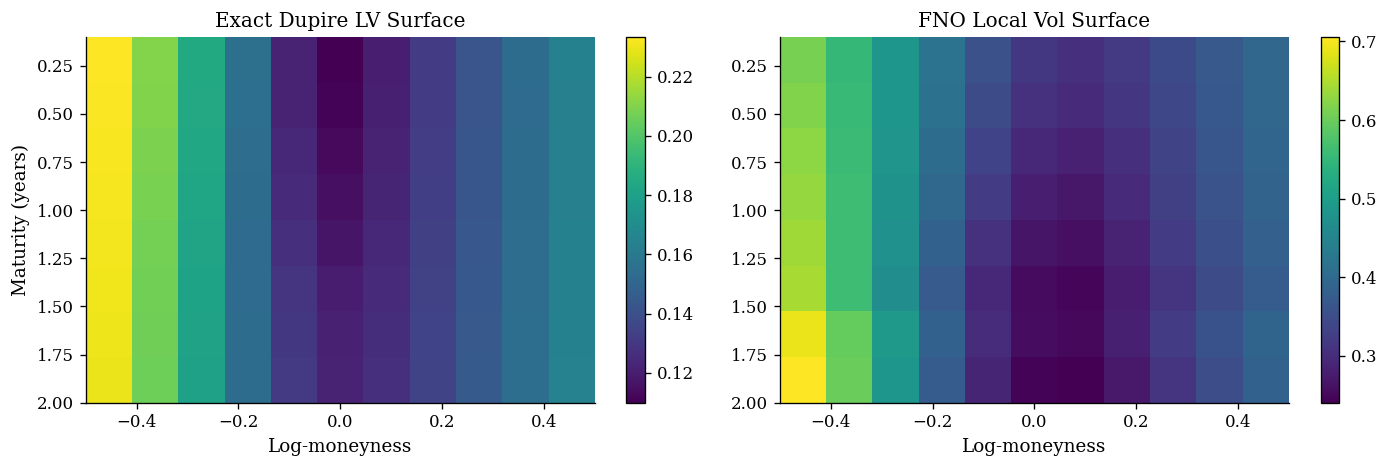

In [4]:
model_lv = MirrorPaddedFNO2d(param_dim=40).to(DEVICE)
model_lv.load_state_dict(torch.load("../artifacts/weights/fno_localvol_final_prod.pth", map_location=DEVICE))
model_lv.eval()

# Calibrate/Evaluate via surrogate
from calibrate import _load_normalizers
_load_normalizers("localvol")
res_lv = compute_local_vol_surface(svi_params.flatten(), T_GRID, K_GRID, use_fno=True, model=model_lv)
lv_pred = res_lv

# Compute MSE
mse = np.mean((lv_exact - lv_pred) ** 2)
print(f"FNO Local Vol Surface MSE vs Exact: {mse:.2e}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im0 = axes[0].imshow(lv_exact, aspect="auto", cmap="viridis", extent=[K_GRID[0], K_GRID[-1], T_GRID[-1], T_GRID[0]])
axes[0].set_title("Exact Dupire LV Surface")
axes[0].set_xlabel("Log-moneyness")
axes[0].set_ylabel("Maturity (years)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(lv_pred, aspect="auto", cmap="viridis", extent=[K_GRID[0], K_GRID[-1], T_GRID[-1], T_GRID[0]])
axes[1].set_title("FNO Local Vol Surface")
axes[1].set_xlabel("Log-moneyness")
plt.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()
